# Pakage export

In [1]:
import os
import kagglehub
import pandas as pd
from scipy.stats import mstats
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

<h1>Data Export</h1>

In [2]:
kagglehub.login()

In [3]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e5')
print("Path to competition files:", path)

Path to competition files: C:\Users\koust\.cache\kagglehub\competitions\playground-series-s6e5


In [4]:
print(os.listdir(path))  # see files

train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))

['sample_submission.csv', 'test.csv', 'train.csv']


<h1>Split Data</h1>

In [5]:
display(train.head())
display(test.head())

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


In [6]:
X = train.drop(columns=['id','PitNextLap'])
y = train['PitNextLap']
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

<h1>EDA</h1>

In [7]:
display(X_train.head())

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
265268,TUR,INTERMEDIATE,Monaco Grand Prix,2023,0,69,3,20.0,4,93.974,0.000,0.000,0.884615,0.0
102155,D064,MEDIUM,Japanese Grand Prix,2023,0,17,1,17.0,5,99.876,-0.001,-0.001,0.320755,0.0
51941,D074,HARD,Australian Grand Prix,2023,0,42,2,34.0,9,84.292,0.263,-8.654,0.724138,0.0
35710,NOR,MEDIUM,British Grand Prix,2023,0,11,1,13.0,2,91.360,-0.236,-3.573,0.211538,0.0
289760,FIT,HARD,Australian Grand Prix,2022,0,45,3,32.0,18,85.000,-9.600,-42.957,0.633803,-2.0


In [8]:
display(X_train['Driver'].nunique())
display(X_train['Race'].nunique())

853

26

#### Is there any duplicate values?

In [9]:
print(X_train.duplicated().sum())

0


#### Shape & types

In [10]:
X_train.shape

(307573, 14)

In [11]:
X_train.dtypes

Driver                        str
Compound                      str
Race                          str
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
dtype: object

In [12]:
X_train.dtypes.value_counts()

float64    6
int64      5
str        3
Name: count, dtype: int64

#### Missing value

In [13]:
X_train.isnull().sum()

Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
dtype: int64

In [14]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

Series([], dtype: int64)

#### Class balance

In [15]:
y_train.value_counts(normalize=True)

PitNextLap
0.0    0.801016
1.0    0.198984
Name: proportion, dtype: float64

#### Correlations

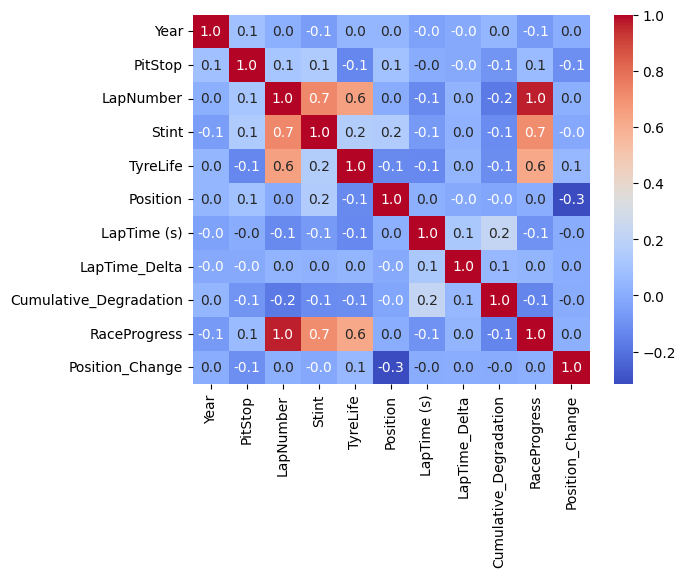

In [16]:
sns.heatmap(X_train.select_dtypes("number").corr(),
            annot=True, fmt= ".1f", cmap="coolwarm")  # anoot true show data inside the those boxs and fmt how many value did you want to show after point
plt.show()

#### Outliers

In [17]:
num_cols = X_train.select_dtypes(include=["number"]).columns
num_cols

Index(['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change'],
      dtype='str')

In [18]:
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask = (X_train[col] < lower) | (X_train[col] > upper)
    print(col, "outliers:", outlier_mask.sum())

Year outliers: 0
PitStop outliers: 41833
LapNumber outliers: 11
Stint outliers: 16867
TyreLife outliers: 4013
Position outliers: 0
LapTime (s) outliers: 4122
LapTime_Delta outliers: 41109
Cumulative_Degradation outliers: 34997
RaceProgress outliers: 0
Position_Change outliers: 42914


In [19]:
col_dic = {}

for col in num_cols:
    col_dic[col] = X_train[col].unique()
for col, values in col_dic.items():
    print(col, ":", values)

Year : [2023 2022 2025 2024]
PitStop : [0 1]
LapNumber : [69 17 42 11 45  7 21 36 50 63 39 44  5 19  8  1 43 27 14 15  6 26 25 49
 20 31 38  9 66 12 51 52  3 40 55 60 18  4 29 33 53 16 13  2 61 24 37 10
 64 23 56 22 54 35 30 47 58 57 34 62 28 48 32 41 68 65 46 59 72 70 67 74
 71 75 77 76 73 78]
Stint : [3 1 2 4 5 6 8 7]
TyreLife : [20.  17.  34.  13.  32.   7.   6.  11.  57.  27.  26.   5.  21.   2.
 19.   8.   1.   9.  31.  14.  15.  23.  25.   4.  48.  12.   3.  22.
 18.  39.  24.  29.  16.  60.  10.  49.  42.  33.  30.  40.  35.  28.
 43.  36.  38.  41.  37.  53.  46.  54.  72.  47.  44.  62.  45.  69.
 66.  55.  50.  59.  58.  56.  64.  65.  70.  71.  67.  52.  61.  51.
 63.  75.  76.  74.  68.  73.  60.5 77. ]
Position : [ 4  5  9  2 18 15 13 11  3  8 12 14  7  6 17 19 16 10  1 20]
LapTime (s) : [93.974 99.876 84.292 ... 70.303 89.51  72.212]
LapTime_Delta : [ 0.0000e+00 -1.0000e-03  2.6300e-01 ... -3.4964e+01 -1.3736e+01
 -6.0390e+00]
Cumulative_Degradation : [ 0.00000e+00 -1.000

# Data Cleaning (Fixing problem which are found in EDA process)


### **Problem**
    1. Highly imbalanced (1 ~ 20%, 0 ~ 80%)
    2. Outliers
    3. Correlated columns

#### ***1. Highly imbalanced (1 ~ 20%, 0 ~ 80%)*** -> **Which I did in Pipeline Section**

#### ***2. Outliers***

In [20]:
skip_cols = ["PitStop", "Position_Change", "Year",
             "LapNumber", "Position", "RaceProgress"]

winsorize_cols = ["Stint", "TyreLife", "LapTime_Delta",
                  "Cumulative_Degradation"]

flag_and_cap_cols = ["LapTime (s)"]

cap_map = {}  # stores {col: (lower, upper)} from training data

# Winsorize
for col in winsorize_cols:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    cap_map[col] = (lo, hi)
    X_train[col] = X_train[col].clip(lower=lo, upper=hi)
    print(f"[{col}] Clipped to [{lo:.2f}, {hi:.2f}]")

# Flag + Winsorize for LapTime (s) — safety car laps are useful signal
for col in flag_and_cap_cols:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    cap_map[col] = (lo, hi)
    X_train[f"is_extreme_{col.replace(' ','_')}"] = (
        (X_train[col] < lo) | (X_train[col] > hi)
    ).astype(int)
    X_train[col] = X_train[col].clip(lower=lo, upper=hi)
    print(f"[{col}] Flagged extremes + clipped to [{lo:.2f}, {hi:.2f}]")

# ── Apply the SAME stored caps to val and test (never refit on them)
for col, (lo, hi) in cap_map.items():
    X_val[col]  = X_val[col].clip(lower=lo, upper=hi)
    X_test[col] = X_test[col].clip(lower=lo, upper=hi)

# Copy the flag column to val and test too
for col in flag_and_cap_cols:
    flag_name = f"is_extreme_{col.replace(' ','_')}"
    lo, hi = cap_map[col]
    X_val[flag_name]  = ((X_val[col] < lo) | (X_val[col] > hi)).astype(int)
    X_test[flag_name] = ((X_test[col] < lo) | (X_test[col] > hi)).astype(int)

print("\nDone. Columns left untouched:", skip_cols)

[Stint] Clipped to [1.00, 5.00]
[TyreLife] Clipped to [1.00, 43.00]
[LapTime_Delta] Clipped to [-40.19, 30.98]
[Cumulative_Degradation] Clipped to [-205.01, 122.06]
[LapTime (s)] Flagged extremes + clipped to [70.72, 124.85]

Done. Columns left untouched: ['PitStop', 'Position_Change', 'Year', 'LapNumber', 'Position', 'RaceProgress']


In [22]:
display(X_train.head())
display(X_train.shape)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,is_extreme_LapTime_(s)
265268,TUR,INTERMEDIATE,Monaco Grand Prix,2023,0,69,3,20.0,4,93.974,0.000,0.000,0.884615,0.0,0
102155,D064,MEDIUM,Japanese Grand Prix,2023,0,17,1,17.0,5,99.876,-0.001,-0.001,0.320755,0.0,0
51941,D074,HARD,Australian Grand Prix,2023,0,42,2,34.0,9,84.292,0.263,-8.654,0.724138,0.0,0
35710,NOR,MEDIUM,British Grand Prix,2023,0,11,1,13.0,2,91.360,-0.236,-3.573,0.211538,0.0,0
289760,FIT,HARD,Australian Grand Prix,2022,0,45,3,32.0,18,85.000,-9.600,-42.957,0.633803,-2.0,0


(307573, 15)

#### ***3. Correlated Columns***
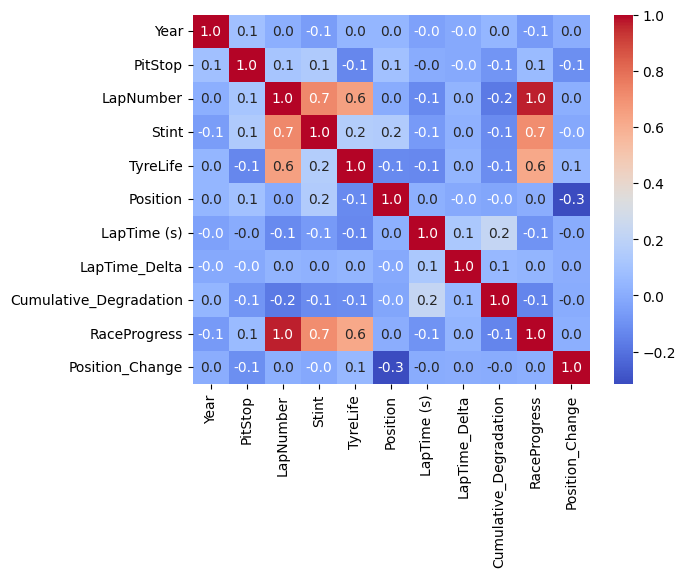

**From above I understand LapNumber and RaceProgress have 1 and one of them I drop and I ignored the values consiste of 0.6 or 0.7**

In [27]:
to_drop = ["LapNumber"]
X_train = X_train.drop(columns=to_drop)
X_val   = X_val.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop)

print("Dropped:", to_drop)
print("Remaining features:", X_train.columns.tolist())


Dropped: ['LapNumber']
Remaining features: ['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'is_extreme_LapTime_(s)']


# Feature Engineering

In [28]:
X_train.dtypes

Driver                        str
Compound                      str
Race                          str
Year                        int64
PitStop                     int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
is_extreme_LapTime_(s)      int64
dtype: object